# Variational Autoencoders (VAE) — a runnable, measured, *proven* build

A plain **autoencoder** compresses an image to a code and rebuilds it — but its latent space is a *bag of holes*: sample a random code and you decode garbage, so you cannot **generate**. A **VAE** fixes this by making the encoder output a *distribution* $q_\phi(z\mid x)=\mathcal N(\mu,\sigma^2 I)$, pulling every posterior toward a smooth prior $\mathcal N(0,I)$ with a **KL** term, and decoding a *sampled* $z$. Then any $z$ drawn from the prior decodes to something real — you can generate.

This notebook builds a VAE **from scratch** on **real** MNIST digits and *proves* the two claims that matter:

- **The closed-form Gaussian KL is exact.** We check with a hard `assert` that the ELBO's KL term $\tfrac12\sum(\mu^2+\sigma^2-1-\log\sigma^2)$ equals a Monte-Carlo estimate of $\mathbb{E}_q[\log q(z\mid x)-\log p(z)]$.
- **The reparameterization trick is what lets gradients train the encoder.** We show, with an `assert`, that $z=\mu+\sigma\odot\varepsilon$ gives real gradients through $\mu,\sigma$, while a raw `.sample()` gives **none**.

It imports the **exact same functions** as the companion page and its figures (from `vae.py`), so the numbers here are the numbers there. Everything is **seeded and CPU-pinned** for a reproducible trace.

> Companion page: **Variational Autoencoders (VAE · ELBO)**. Run top-to-bottom (Kernel → Restart & Run All). If MNIST can't be downloaded, the module falls back to the real `sklearn` `load_digits` 8x8 set — every run still executes on real image data.

## Step 0 — Setup: import the real module and print versions

We import the pipeline from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions and the device. Training pins **CPU** for a reproducible trace (a small MLP VAE trains fast enough on CPU).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import vae as V

try:
    import torchvision
    tv_ver = torchvision.__version__
except Exception:
    tv_ver = 'not installed'
print(f'torch {torch.__version__} | numpy {np.__version__} | torchvision {tv_ver}')
print(f'best available device = {V.get_device()}  (training pinned to CPU for reproducibility, seed={V.SEED})')

torch 2.12.0 | numpy 2.4.6 | torchvision 0.27.0
best available device = mps  (training pinned to CPU for reproducibility, seed=0)


## Step 1 — The data: real MNIST digits as pixel probabilities in [0, 1]

We load a real subset of **MNIST** (28×28 grayscale handwritten digits), flattened to 784-dim vectors with pixels in $[0,1]$. We treat each pixel as the mean of a **Bernoulli** — the decoder will output a probability per pixel. (If MNIST can't be fetched, the module falls back to the real `sklearn` 8×8 digits; the banner says which.)

dataset : MNIST (28x28)   [mnist]
train   : (12000, 784)   test: (2000, 784)   pixels/image: 784


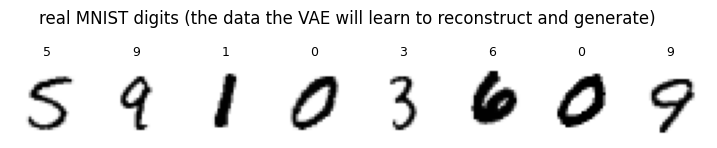

In [2]:
data = V.load_data()
print(f'dataset : {data.label}   [{data.source}]')
print(f'train   : {tuple(data.x_train.shape)}   test: {tuple(data.x_test.shape)}   pixels/image: {data.n_pixels}')

h, w = data.img_shape
fig, axes = plt.subplots(1, 8, figsize=(9, 1.4))
for j in range(8):
    axes[j].imshow(data.x_test[j].numpy().reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[j].set_title(str(int(data.y_test[j])), fontsize=9)
    axes[j].axis('off')
plt.suptitle('real MNIST digits (the data the VAE will learn to reconstruct and generate)', y=1.15)
plt.show()

## Step 2 — The VAE: a Gaussian encoder and a Bernoulli decoder

The **encoder** maps an image to the parameters of an approximate posterior $q_\phi(z\mid x)=\mathcal N(\mu(x),\operatorname{diag}\sigma^2(x))$ — a mean $\mu$ and a *log-variance* $\log\sigma^2$ (predicting the log keeps it unconstrained and stable). The **decoder** maps $z$ back to per-pixel Bernoulli **logits**. Note the latent is just **2-D** here — small enough that we can later *draw* the whole latent space.

In [3]:
model = V.VAE(data.n_pixels, latent_dim=V.LATENT_DIM)
xb = data.x_test[:5]
mu, logvar = model.encode(xb)
print(f'latent dim      : {model.latent_dim}')
print(f'encoder outputs : mu {tuple(mu.shape)}, logvar {tuple(logvar.shape)}  (one (mu, logsigma^2) per image)')
print(f'mu[0]           : {mu[0].detach().numpy().round(3)}')
print(f'logvar[0]       : {logvar[0].detach().numpy().round(3)}  (untrained -> near 0 => sigma^2 ~ 1)')

latent dim      : 2
encoder outputs : mu (5, 2), logvar (5, 2)  (one (mu, logsigma^2) per image)
mu[0]           : [-0.041 -0.007]
logvar[0]       : [-0.041 -0.028]  (untrained -> near 0 => sigma^2 ~ 1)


## Step 3 — The reparameterization trick: sample $z$ *differentiably*

To train end-to-end we must sample $z\sim\mathcal N(\mu,\sigma^2)$ — but sampling is not a differentiable function of $\mu,\sigma$, so gradients cannot flow back to the encoder. The trick: move the randomness into a **parameter-free** $\varepsilon\sim\mathcal N(0,I)$ and reconstruct $z$ by a differentiable affine map,

$$z = \mu + \sigma\odot\varepsilon,\qquad \sigma=\exp(\tfrac12\log\sigma^2).$$

Now $\partial z/\partial\mu=1$ and $\partial z/\partial\sigma=\varepsilon$ are well defined.

In [4]:
z = model.reparameterize(mu, logvar)
print(f'z = mu + sigma * eps  ->  z shape {tuple(z.shape)}')
print(f'z[0]      : {z[0].detach().numpy().round(3)}   (mu[0] plus noise scaled by sigma)')
print(f'z requires_grad = {z.requires_grad}  (differentiable in mu, logvar -> the encoder can be trained)')

z = mu + sigma * eps  ->  z shape (5, 2)
z[0]      : [0.041 0.591]   (mu[0] plus noise scaled by sigma)
z requires_grad = True  (differentiable in mu, logvar -> the encoder can be trained)


## Step 4 — Proof: the trick is *why* the encoder can be trained

Claim: $z=\mu+\sigma\varepsilon$ gives gradients through $\mu,\sigma$, while a raw `torch.distributions.Normal(mu, sigma).sample()` gives **none** (it detaches $z$ from the encoder). We build a tiny loss $\lVert z\rVert^2$ both ways and check the gradients. `assert` it.

In [5]:
rp = V.prove_reparameterization()
print('reparameterized z = mu + sigma*eps :')
print(f'   ||d loss / d mu||     = {rp.grad_mu_reparam:.3f}   (gradient flows)')
print(f'   ||d loss / d logvar|| = {rp.grad_logvar_reparam:.3f}   (gradient flows)')
print(f'direct .sample() z :   z.requires_grad = {rp.direct_sample_has_grad}   (NO gradient to encoder)')
assert rp.grad_mu_reparam > 1e-6 and rp.grad_logvar_reparam > 1e-6
assert rp.direct_sample_has_grad is False
print('OK: reparameterization gives gradients where a raw sample gives none — this is why we reparameterize.')

reparameterized z = mu + sigma*eps :
   ||d loss / d mu||     = 5.489   (gradient flows)
   ||d loss / d logvar|| = 5.318   (gradient flows)
direct .sample() z :   z.requires_grad = False   (NO gradient to encoder)
OK: reparameterization gives gradients where a raw sample gives none — this is why we reparameterize.


## Step 5 — The loss: the (negative) ELBO = reconstruction + KL-to-prior

We maximize the **Evidence Lower BOund**

$$\log p(x)\ \ge\ \underbrace{\mathbb{E}_q[\log p_\theta(x\mid z)]}_{\text{reconstruction}}\ -\ \underbrace{\mathrm{KL}(q_\phi(z\mid x)\,\|\,\mathcal N(0,I))}_{\text{regularizer}},$$

i.e. minimize its negation. **Reconstruction** is the per-pixel binary cross-entropy (the Bernoulli negative log-likelihood). **KL** uses the closed form $\tfrac12\sum(\mu^2+\sigma^2-1-\log\sigma^2)$. Both are per-image means.

In [6]:
logits, mu, logvar = model(xb)
loss, recon, kl = V.elbo_loss(logits, xb, mu, logvar, beta=1.0)
print('negative ELBO = recon + KL')
print(f'   reconstruction (BCE, summed over pixels) = {recon.item():.2f}')
print(f'   KL(q || N(0,I))  closed form             = {kl.item():.2f}')
print(f'   total negative ELBO                      = {loss.item():.2f}   (untrained: high)')

negative ELBO = recon + KL
   reconstruction (BCE, summed over pixels) = 550.75
   KL(q || N(0,I))  closed form             = 0.00
   total negative ELBO                      = 550.76   (untrained: high)


## Step 6 — Proof: the closed-form KL *is* the KL

The KL term is a *closed form*, but the **definition** of KL is an expectation, $\mathrm{KL}(q\|p)=\mathbb{E}_{z\sim q}[\log q(z)-\log p(z)]$. If the closed form is right, sampling $z\sim q$ and averaging $\log q(z\mid x)-\log p(z)$ must converge to it. We `assert` they agree.

In [7]:
kp = V.prove_gaussian_kl(n_samples=400_000)
print(f'closed form  1/2 sum(mu^2 + sigma^2 - 1 - logvar) = {kp.closed_form:.5f}')
print(f'Monte-Carlo  E_q[log q(z|x) - log p(z)]  (N={kp.n_samples:,}) = {kp.monte_carlo:.5f}')
print(f'|closed - MC| = {kp.abs_error:.2e}')
assert kp.abs_error < 1e-2
print('OK: the ELBO KL term is exactly KL(q || p) — the term the loss uses is the term the math claims.')

closed form  1/2 sum(mu^2 + sigma^2 - 1 - logvar) = 3.94278
Monte-Carlo  E_q[log q(z|x) - log p(z)]  (N=400,000) = 3.94042
|closed - MC| = 2.37e-03
OK: the ELBO KL term is exactly KL(q || p) — the term the loss uses is the term the math claims.


## Step 7 — Train from scratch on real MNIST

Now the full loop: for each minibatch, encode → reparameterize → decode → negative ELBO → one Adam step. We train the headline model ($\beta=1$, 2-D latent) and watch the total loss fall, split into its reconstruction and KL parts. (A real training run — a couple of minutes on CPU.)

trained 15 epochs  |  final negative-ELBO = 160.92  (recon 155.37 + KL 5.54)


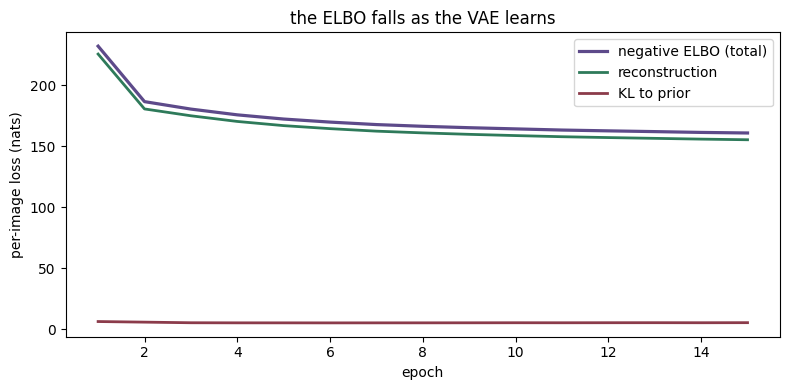

In [8]:
res = V.train_vae(data, beta=1.0, latent_dim=V.LATENT_DIM, n_epochs=V.N_EPOCHS, seed=0)
print(f'trained {V.N_EPOCHS} epochs  |  final negative-ELBO = {res.final_elbo:.2f}  (recon {res.final_recon:.2f} + KL {res.final_kl:.2f})')

ep = np.arange(1, len(res.elbo) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ep, res.elbo, color='#5D4A8A', lw=2.3, label='negative ELBO (total)')
ax.plot(ep, res.recon, color='#2E7A5A', lw=2, label='reconstruction')
ax.plot(ep, res.kl, color='#8B3B4A', lw=2, label='KL to prior')
ax.set_xlabel('epoch')
ax.set_ylabel('per-image loss (nats)')
ax.set_title('the ELBO falls as the VAE learns')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Reconstruct: encode real digits and decode them back

The first thing the VAE can do: compress a real held-out digit to its 2-D code and rebuild it. The reconstructions are recognizable but a little **blurry** — the Gaussian/Bernoulli likelihood averages over the posterior, an honest and characteristic VAE trait (GANs and diffusion are sharper).

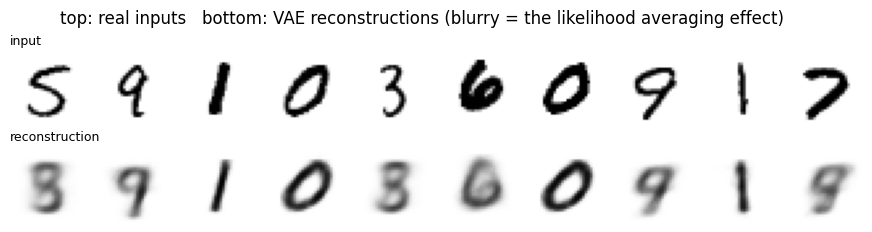

In [9]:
x = data.x_test[:10]
recon = V.reconstruct(res.model, x)
fig, axes = plt.subplots(2, 10, figsize=(11, 2.3))
for j in range(10):
    axes[0, j].imshow(x[j].numpy().reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[1, j].imshow(recon[j].reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[0, j].axis('off')
    axes[1, j].axis('off')
axes[0, 0].set_title('input', fontsize=9, loc='left')
axes[1, 0].set_title('reconstruction', fontsize=9, loc='left')
plt.suptitle('top: real inputs   bottom: VAE reconstructions (blurry = the likelihood averaging effect)', y=1.05)
plt.show()

## Step 9 — Generate: sample $z\sim\mathcal N(0,I)$ and decode

This is the payoff a plain autoencoder cannot give. Because the KL term forced the encoded posteriors to fill the prior, we can sample a **fresh** $z$ from $\mathcal N(0,I)$ and decode it into a *new* digit the model dreamed up — never in the training set. That is what makes a VAE a **generative** model.

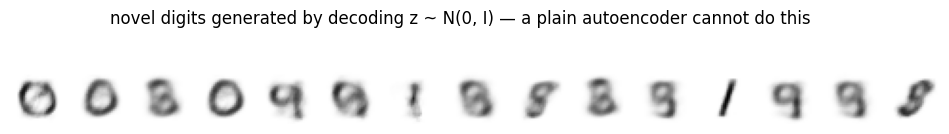

In [10]:
samples = V.sample_prior(res.model, n=15, seed=1)
fig, axes = plt.subplots(1, 15, figsize=(12, 1.1))
for j in range(15):
    axes[j].imshow(samples[j].reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[j].axis('off')
plt.suptitle('novel digits generated by decoding z ~ N(0, I) — a plain autoencoder cannot do this', y=1.3)
plt.show()

## Step 10 — See the whole latent space: the 2-D manifold

Because the latent is 2-D, we can decode a **grid** of $z$ across the prior and lay the results out. Neighbours in $z$ decode to visually similar digits, and the classes are organized into contiguous regions with smooth transitions between them — a continuous, sampleable space, not a bag of holes.

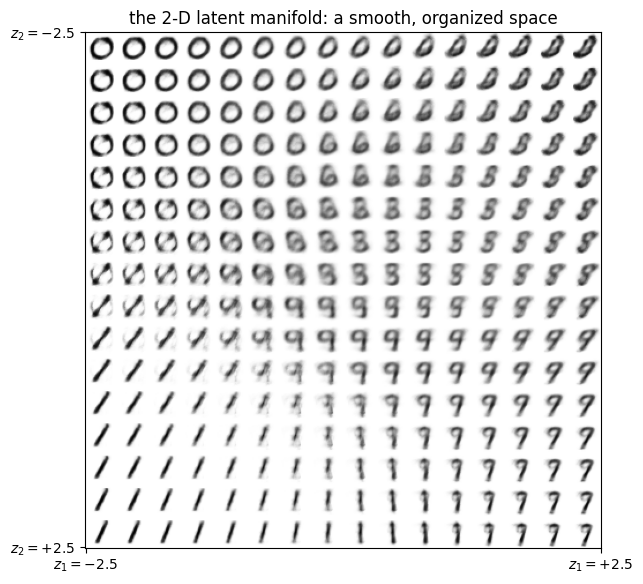

In [11]:
grid = 16
tiles = V.latent_manifold(res.model, grid=grid, span=2.5)
canvas = np.zeros((grid * h, grid * w))
for idx in range(grid * grid):
    r, c = divmod(idx, grid)
    canvas[r*h:(r+1)*h, c*w:(c+1)*w] = tiles[idx].reshape(h, w)
plt.figure(figsize=(6.5, 6.5))
plt.imshow(canvas, cmap='gray_r', vmin=0, vmax=1)
plt.xticks([0, grid*w-1], ['$z_1=-2.5$', '$z_1=+2.5$'])
plt.yticks([0, grid*h-1], ['$z_2=-2.5$', '$z_2=+2.5$'])
plt.title('the 2-D latent manifold: a smooth, organized space')
plt.tight_layout()
plt.show()

## Step 11 — Interpolate: walk a straight line between two digits

One more window on the smoothness: encode two different digits, linearly interpolate between their latent codes, and decode each step. The frames **morph** gradually from one digit into the other — no abrupt cuts. That continuity is exactly what the KL-to-prior regularizer buys.

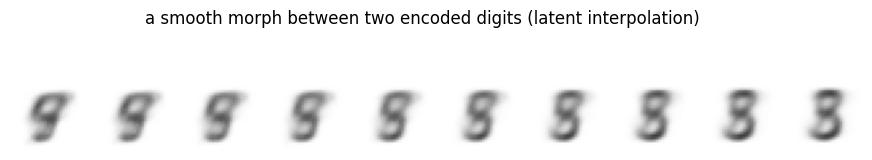

In [12]:
y = data.y_test
def first_of(label, fb):
    idx = np.flatnonzero(y == label)
    return int(idx[0]) if idx.size else fb
i0, i1 = first_of(7, 0), first_of(3, 1)
frames = V.interpolate(res.model, data.x_test[i0], data.x_test[i1], steps=10)
fig, axes = plt.subplots(1, 10, figsize=(11, 1.3))
for j in range(10):
    axes[j].imshow(frames[j].reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[j].axis('off')
plt.suptitle('a smooth morph between two encoded digits (latent interpolation)', y=1.3)
plt.show()

## Step 12 — The $\beta$-VAE knob: trade reconstruction against KL

Weight the KL term by $\beta$. With $\beta>1$ the encoder is pulled **harder** toward the prior — a *smaller* KL (tighter, more disentangled latent) but at the cost of **worse reconstruction**. Train $\beta=1$ and $\beta=4$ and read the trade-off off the two terms. We `assert` the direction.

In [13]:
r1 = res  # beta=1 already trained above
r4 = V.train_vae(data, beta=4.0, latent_dim=V.LATENT_DIM, n_epochs=V.N_EPOCHS, seed=0)
print(f'beta=1:  recon = {r1.final_recon:6.2f}   KL = {r1.final_kl:5.2f}')
print(f'beta=4:  recon = {r4.final_recon:6.2f}   KL = {r4.final_kl:5.2f}')
assert r4.final_kl < r1.final_kl        # larger beta -> tighter to prior (smaller KL)
assert r4.final_recon > r1.final_recon  # ...at the cost of reconstruction
print('OK: larger beta buys a smaller KL at the cost of reconstruction — the disentanglement/sharpness trade-off.')

beta=1:  recon = 155.37   KL =  5.54
beta=4:  recon = 161.39   KL =  3.30
OK: larger beta buys a smaller KL at the cost of reconstruction — the disentanglement/sharpness trade-off.


## Step 13 — Try it: predict, then check

Before running, *predict the direction*. **(1)** Push $\beta$ to **10**: will the reconstructions get sharper or blurrier, and will the KL shrink further — possibly toward **posterior collapse** (KL → 0, the decoder ignoring $z$)? **(2)** Raise the latent dim from 2 to **10**: will reconstruction improve, and can you still draw the manifold? Write your guess, change the one line, and check.

beta=10: recon = 171.15   KL =  1.94  (KL shrinks further -> the road to posterior collapse)


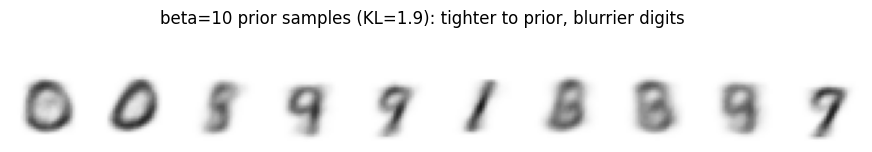

In [14]:
r10 = V.train_vae(data, beta=10.0, latent_dim=V.LATENT_DIM, n_epochs=V.N_EPOCHS, seed=0)
print(f'beta=10: recon = {r10.final_recon:6.2f}   KL = {r10.final_kl:5.2f}  '
      f'(KL shrinks further -> the road to posterior collapse)')
samples10 = V.sample_prior(r10.model, n=10, seed=1)
fig, axes = plt.subplots(1, 10, figsize=(11, 1.2))
for j in range(10):
    axes[j].imshow(samples10[j].reshape(h, w), cmap='gray_r', vmin=0, vmax=1)
    axes[j].axis('off')
plt.suptitle(f'beta=10 prior samples (KL={r10.final_kl:.1f}): tighter to prior, blurrier digits', y=1.3)
plt.show()

## Recap

You built a VAE from scratch and **proved** it: the closed-form Gaussian KL matches a Monte-Carlo estimate of $\mathrm{KL}(q\|p)$ (the loss uses the exact term), and the **reparameterization trick** $z=\mu+\sigma\varepsilon$ gives gradients through the encoder where a raw `.sample()` gives none. A VAE trained by minimizing the negative ELBO learns to **reconstruct** real digits, **generate** novel ones from the prior, and organize a **smooth 2-D latent manifold** you can interpolate across — and the $\beta$ knob trades reconstruction against a tighter latent, all the way to posterior collapse.

See the companion page for the full derivation (the intractable marginal, the ELBO and its KL-gap identity, why the reparameterization lowers gradient variance versus the score-function estimator), the pitfalls (posterior collapse, blurry samples, the aggregate-posterior/prior mismatch), and where it goes next: the VAE is the **latent space of latent diffusion (Stable Diffusion)**, and its one-step latent-variable model is the conceptual seed of **diffusion**.